In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [4]:
# Website URL
url = "https://books.toscrape.com/"

# Send a request to the website
response = requests.get(url)

# Print the status code
print(response.status_code)

200


In [7]:
# Parse the HTML content
soup = BeautifulSoup(response.text, "html.parser")

In [9]:
print(soup.prettify()[:1000])

<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!-->
<html class="no-js" lang="en-us">
 <!--<![endif]-->
 <head>
  <title>
   All products | Books to Scrape - Sandbox
  </title>
  <meta content="text/html; charset=utf-8" http-equiv="content-type"/>
  <meta content="24th Jun 2016 09:29" name="created"/>
  <meta content="" name="description"/>
  <meta content="width=device-width" name="viewport"/>
  <meta content="NOARCHIVE,NOCACHE" name="robots"/>
  <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
  <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->
  <link href="static/oscar/favicon.ico" rel="shortcut icon"/>
  <link href="static/oscar/css/styles.css" rel="stylesheet" type="tex

In [11]:
# Find all book containers
book_list = soup.find_all("article", class_="product_pod")

# Check how many books were found
print(len(book_list))

20


In [13]:
first_book = book_list[0]

print(first_book)

<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">Â£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>


In [15]:
title = first_book.h3.a["title"]

print(title)

A Light in the Attic


In [17]:
price = first_book.find("p", class_="price_color").text

print(price)

Â£51.77


In [19]:
rating = first_book.p["class"][1]

print(rating)

Three


In [21]:
availability = first_book.find("p", class_="instock availability").text.strip()

print(availability)

In stock


In [23]:
# Create an empty list to store all books
books = []

# Loop through each book
for book in book_list:

    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.p["class"][1]
    availability = book.find("p", class_="instock availability").text.strip()

    books.append([title, price, rating, availability])

print(books)

[['A Light in the Attic', 'Â£51.77', 'Three', 'In stock'], ['Tipping the Velvet', 'Â£53.74', 'One', 'In stock'], ['Soumission', 'Â£50.10', 'One', 'In stock'], ['Sharp Objects', 'Â£47.82', 'Four', 'In stock'], ['Sapiens: A Brief History of Humankind', 'Â£54.23', 'Five', 'In stock'], ['The Requiem Red', 'Â£22.65', 'One', 'In stock'], ['The Dirty Little Secrets of Getting Your Dream Job', 'Â£33.34', 'Four', 'In stock'], ['The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull', 'Â£17.93', 'Three', 'In stock'], ['The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics', 'Â£22.60', 'Four', 'In stock'], ['The Black Maria', 'Â£52.15', 'One', 'In stock'], ['Starving Hearts (Triangular Trade Trilogy, #1)', 'Â£13.99', 'Two', 'In stock'], ["Shakespeare's Sonnets", 'Â£20.66', 'Four', 'In stock'], ['Set Me Free', 'Â£17.46', 'Five', 'In stock'], ["Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)", 'Â£52.29', 'Five', 'In s

In [25]:
df = pd.DataFrame(
    books,
    columns=["Title", "Price", "Rating", "Availability"]
)

df

,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock
5,The Requiem Red,Â£22.65,One,In stock
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,Four,In stock
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,Three,In stock
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,Four,In stock
9,The Black Maria,Â£52.15,One,In stock


In [27]:
df.to_csv("scraped_data.csv", index=False)

print("Data saved successfully!")

Data saved successfully!


In [29]:
from google.colab import files

files.download("scraped_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
books = []

# Loop through all 50 pages
for page in range(1, 51):

    if page == 1:
        url = "https://books.toscrape.com/"
    else:
        url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    book_list = soup.find_all("article", class_="product_pod")

    for book in book_list:

        title = book.h3.a["title"]

        price = book.find("p", class_="price_color").text

        rating = book.p["class"][1]

        availability = book.find(
            "p",
            class_="instock availability"
        ).text.strip()

        books.append([
            title,
            price,
            rating,
            availability
        ])

print("Total books scraped:", len(books))

Total books scraped: 1000


In [33]:
df = pd.DataFrame(
    books,
    columns=[
        "Title",
        "Price",
        "Rating",
        "Availability"
    ]
)

df.head()


,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [36]:
df.shape


(1000, 4)

In [38]:
df.to_csv("scraped_books_1000.csv", index=False)

print("CSV saved successfully!")

CSV saved successfully!


In [40]:
df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [42]:
df.tail()

,Title,Price,Rating,Availability
995,Alice in Wonderland (Alice's Adventures in Won...,Â£55.53,One,In stock
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",Â£57.06,Four,In stock
997,A Spy's Devotion (The Regency Spies of London #1),Â£16.97,Five,In stock
998,1st to Die (Women's Murder Club #1),Â£53.98,One,In stock
999,"1,000 Places to See Before You Die",Â£26.08,Five,In stock


In [44]:
df.shape

(1000, 4)

In [46]:
# Total number of books
print("Total Books:", len(df))

Total Books: 1000


In [48]:
# Check the ratings distribution
print(df["Rating"].value_counts())

Rating
One      226
Three    203
Five     196
Two      196
Four     179
Name: count, dtype: int64


In [50]:
# Check availability
print(df["Availability"].value_counts())

Availability
In stock    1000
Name: count, dtype: int64


In [52]:
# Basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         1000 non-null   object
 1   Price         1000 non-null   object
 2   Rating        1000 non-null   object
 3   Availability  1000 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB


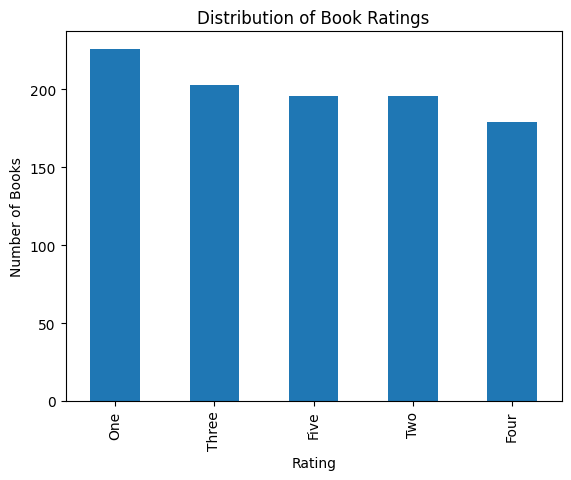

In [54]:
import matplotlib.pyplot as plt

# Count ratings
rating_counts = df["Rating"].value_counts()

# Create bar chart
rating_counts.plot(kind="bar")

# Add title and labels
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()

In [55]:
from google.colab import files

files.download("scraped_books_1000.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>